# 핵심 키워드 추출

대상 기사
 * 제목: '구글, 제미나이4 플래그십 AI '아르곤' 공개…오픈AI·앤트로픽 추격'
 * 언론사: 뉴스1
 * URL: https://n.news.naver.com/article/421/0009202052

---

## 0. 환경 설정
### 0-1. 데이터 준비

In [6]:
%pip install networkx

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 9.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
import re
import time
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx

warnings.filterwarnings("ignore")

In [8]:
KO_DOC_META = {
    'title': '구글, 제미나이4 플래그십 AI "아르곤" 공개…오픈AI·앤트로픽 추격',
    'press': '뉴스1',
    'url': 'https://n.news.naver.com/article/421/0009202052',
}

KO_DOC = '''구글이 수개월간 출시를 미뤘던 차세대 인공지능(AI) 모델 '제미나이 4'를 공개했다. 구글은 제미나이 4의 최상위 모델 '아르곤(Argon)'을 앞세워 오픈AI와 앤트로픽을 추격한다는 전략을 세워두고 있다.

30일(현지시간) 로이터통신에 따르면 구글은 이날 제미나이 4 모델군 플래그십 모델 아르곤을 발표했다. 구글은 아르곤이 기존 제미나이 최상위 '프로(Pro)' 계열보다 규모가 큰 모델이라고 설명했다.

구글은 아르곤에 대해 "복잡한 작업을 위해 개발한 지금까지 가장 뛰어난 성능의 모델"이라며 "주요 코딩과 사이버보안 벤치마크에서 오픈AI '아스트라'와 앤트로픽 '오퍼스' 등 최첨단 모델과 견줄 만한 수준"이라고 소개했다.

구글은 일부 사이버보안 협력업체에 아르곤을 우선 제공하기로 했다. 구글은 도널드 트럼프 미 행정부가 운영하는 AI 모델 출시 전 사전 접근 자율 프로그램에도 참여하고 있다고 밝혔다.

다만 구글은 일반 이용자를 대상으로 한 아르곤 공개 일정은 밝히지 않았다.

최근 생성형 AI 업계에선 오픈AI와 앤트로픽의 기업용·개발자 시장 공세가 거세지고 있다. 구글은 제미나이 4와 아르곤을 앞세워 코딩과 사이버보안 등 고난도 전문 분야에서 경쟁력을 강화한다는 방침이다. '''

print(KO_DOC_META['title'])
print(f'총 {len(KO_DOC)}자')

구글, 제미나이4 플래그십 AI "아르곤" 공개…오픈AI·앤트로픽 추격
총 616자


### 0-2. 전처리

In [9]:
from konlpy.tag import Komoran

# 사용자 사전 - 고유명사
# 분석기가 쪼개 버리는 고유명사·복합명사를 한 단어로 묶어준다
USER_DIC = """\
제미나이\tNNP
아르곤\tNNP
오픈AI\tNNP
앤트로픽\tNNP
아스트라\tNNP
오퍼스\tNNP
로이터통신\tNNP
도널드 트럼프\tNNP
사이버보안\tNNG
플래그십\tNNG
벤치마크\tNNG
최상위\tNNG
현지시간\tNNG
"""

with open("user_dic.txt", "w", encoding="utf-8") as f:
    f.write(USER_DIC)

komoran = Komoran(userdic="./user_dic.txt")
print(komoran.pos("구글이 제미나이 4의 최상위 모델 아르곤을 앞세워 오픈AI와 앤트로픽을 추격한다."))

[('구글', 'NNP'), ('이', 'JKS'), ('제미나이', 'NNP'), ('4', 'SN'), ('의', 'JKG'), ('최상위', 'NNG'), ('모델', 'NNP'), ('아르곤', 'NNP'), ('을', 'JKO'), ('앞세우', 'VV'), ('어', 'EC'), ('오픈AI', 'NNP'), ('와', 'JC'), ('앤트로픽', 'NNP'), ('을', 'JKO'), ('추격', 'NNG'), ('하', 'XSV'), ('ㄴ다', 'EF'), ('.', 'SF')]


In [ ]:
# 불용어
STOP_WORDS = set("""
것 등 수 때 중 점 내 외 위 뒤 앞 안 밖 곳 만큼 가지 대비 기준 경우 관련 통해 대해 위해
하다 되다 있다 없다 이다 아니다 같다 보다 두다 오다 가다 내다 지다 늘다 크다 많다 적다
위하다 대하다 통하다 따르다 이번 지난 최근 올해 내년 현재 향후 이후 이전 지난해 전년 동기 기간
우리 그것 이것 이런 그런 이어 다만 특히 또한 함께 가장 매우 이미 실제 대한 각각
기자 사진 제공 자료 출처 보도 외신 업계 회사 소개 공개 발표 진행 확대 강화 말
현지시간 이날 지금 일부
""".split())
# 한 글자지만 의미가 있는 명사
KEEP_ONE_CHAR = {"칩", "팀", "랙", "차", "웹", "앱", "폰", "법"}

def clean_text(text):
    text = re.sub(r"\([^)]*@[^)]*\)", " ", text)       # (기자 이메일) 제거
    text = re.sub(r"https?://\S+", " ", text)           # URL 제거
    text = re.sub(r"[^가-힣A-Za-z0-9\s\.\,\?\!\'\"%\-\(\)]", " ", text)  # 특수문자 제거
    return re.sub(r"\s+", " ", text).strip()            # 공백 정리

def get_nouns(text):
    out = []
    for w, p in komoran.pos(clean_text(text)):
        if p not in ("NNG", "NNP", "SL"):
            continue
        if p == "SL":
            w = w.upper()
        if w in STOP_WORDS:
            continue
        if len(w) == 1 and w not in KEEP_ONE_CHAR:
            continue
        out.append(w.replace(" ", "_"))
    return out

# 한국어 문장 분리
SENT_RE = re.compile(r'(?<=[.!?])\s+(?=["\'(가-힣A-Z0-9])')

def split_sentences_ko(text):
    tmp = re.sub(r"(\d)\.(\d)", r"\1<DOT>\2", clean_text(text))
    return [s.replace("<DOT>", ".").strip() for s in SENT_RE.split(tmp) if s.strip()]

tokens = get_nouns(KO_DOC)
sentences = split_sentences_ko(KO_DOC)
print(f"토큰 {len(tokens)}개 / 고유 {len(set(tokens))}개 / 문장 {len(sentences)}개")
print(tokens[:15])
print(sentences[0])

토큰 91개 / 고유 56개 / 문장 10개
['구글', '수개월', '출시', '차세대', '인공지능', 'AI', '모델', '제미나이', '구글', '제미나이', '최상위', '모델', '아르곤', 'ARGON', '오픈AI']
구글이 수개월간 출시를 미뤘던 차세대 인공지능(AI) 모델 '제미나이 4'를 공개했다.


---
## 1. TextRank 로 핵심 키워드 추출

**아이디어** : 문서를 *단어 그래프*로 바꾼다.

- **노드(vertex)** = 단어 (여기서는 명사)
- **엣지(edge)** = 두 단어가 크기 `window_size` 의 창 안에 함께 등장하면 연결, 가중치는 동시등장 횟수
- 그래프 위에서 PageRank 를 돌려 **"중요한 단어에게 많이 연결된 단어"** 를 찾는다

### 1-1. 단어 그래프 만들기

In [11]:
def build_word_graph(tokens, window_size=2):
    """
    tokens      : 토큰 리스트
    window_size : 이 크기의 창 안에 함께 나오면 엣지를 연결
    return      : (가중 인접행렬 W, 어휘 리스트)
    """
    vocab = sorted(set(tokens))
    w2i = {w: i for i, w in enumerate(vocab)}
    n = len(vocab)
    W = np.zeros((n, n), dtype=np.float64)

    for s in range(len(tokens) - window_size + 1):
        win = tokens[s:s + window_size]
        for i in range(len(win)):
            for j in range(i + 1, len(win)):
                a, b = w2i[win[i]], w2i[win[j]]
                if a == b:
                    continue
                W[a][b] += 1             # 무방향 그래프
                W[b][a] += 1
    return W, vocab


W, vocab = build_word_graph(tokens, window_size=2)
print(f"노드 {len(vocab)}개 / 엣지 {int((W > 0).sum() / 2)}개")

노드 56개 / 엣지 78개


### 1-2. 반복 계산으로 스코어 수렴시키기

* 모든 노드의 점수를 1로 초기화한 뒤, 위 식을 값이 변하지 않을 때까지 반복
* `d`(damping factor, 감쇠계수) = PageRank = 0.85

In [12]:
def textrank_score(W, d=0.85, max_iter=100, tol=1e-6):
    """가중 인접행렬 W 에 대해 TextRank(=가중 PageRank) 스코어를 반복 계산"""
    n = W.shape[0]
    out = W.sum(axis=1)
    out[out == 0] = 1                    # 엣지가 없는 노드 나눗셈 처리
    A = W / out[:, None]                 # 행 정규화 : 자기 점수를 이웃에게 나눠준다

    score = np.ones(n)                   # 모든 노드 1로 초기화
    for it in range(max_iter):
        new = (1 - d) + d * A.T.dot(score)
        if np.abs(new - score).sum() <= tol:
            return new, it + 1           # 수렴
        score = new
    return score, max_iter

score, iters = textrank_score(W)
print(f"{iters}회 반복 후 수렴")

df_kw = pd.DataFrame({
    "키워드": vocab,
    "TextRank": score.round(4),
    "빈도": [tokens.count(v) for v in vocab],
    "연결 노드 수": (W > 0).sum(axis=1),
}).sort_values("TextRank", ascending=False).reset_index(drop=True)
df_kw.index += 1
df_kw.head(15)

70회 반복 후 수렴


,키워드,TextRank,빈도,연결 노드 수
1,구글,4.2130,9,11
2,모델,3.9977,8,12
3,아르곤,3.4461,7,10
4,제미나이,2.3111,5,5
5,앤트로픽,1.8301,3,5
6,오픈AI,1.7059,3,5
7,AI,1.6898,3,5
8,사이버보안,1.6527,3,6
9,출시,1.2625,2,4
10,경쟁력,1.1003,1,2


---
### TextRank 의 원리 (PageRank 와의 유사점·차이점)

#### TextRank 의 기본 원리

TextRank는 **"중요한 것은 중요한 것들과 연결되어 있다"** 는 재귀적 정의를 텍스트에 적용한 알고리즘이다.

동작은 네 단계다.

1. **텍스트를 그래프로 바꾼다.** 무엇을 노드로 볼지에 따라 용도가 갈린다.
   - 키워드 추출 → 노드 = 단어, 엣지 = 창(window) 안 동시등장
   - 문서 요약 → 노드 = 문장, 엣지 = 문장 간 유사도
2. **엣지에 가중치를 준다.** 여기선 window 안에서 함께 나온 횟수를 가중치로 썼다.
3. **각 노드의 점수를 1로 초기화하고 반복 계산한다.** 자기 점수를 이웃에게 나눠주고,
   이웃에게서 받은 점수를 합산하는 과정을 수렴할 때까지 반복한다.
4. **점수 순으로 정렬해 상위 N개를 뽑는다.**

#### PageRank 와의 유사점

| 항목 | 공통점 |
|---|---|
| 핵심 아이디어 | 중요한 노드로부터 링크를 많이 받은 노드가 중요하다는 **재귀적 정의** |
| d | 0.85 를 그대로 사용 |
| 계산 방식 | 반복으로 초기값과 무관하게 같은 값으로 수렴 |
| 비지도 | 정답 라벨이나 학습 데이터가 전혀 필요 없음 |

#### PageRank 와의 차이점

| 항목 | PageRank | TextRank |
|---|---|---|
| **노드** | 웹 페이지 | 단어 또는 문장 |
| **엣지** | 하이퍼링크 — **사람이 실제로 만들어 둔 것** | 동시등장·유사도 — **알고리즘이 계산해서 만들어낸 것** |
| **방향성** | 있다 | 없다 |
| **가중치** | 원래는 없음(모든 링크 동등) | **가중 그래프가 기본**. 동시등장 횟수, 유사도 값이 곧 가중치 |
| **그래프 크기** | 수십억 노드, 매우 희소 | 문서 하나면 수백 노드 수준 |
| **정규화** | 확률분포(총합 1) | 원 논문은 정규화하지 않음 |
| **목적** | 검색 결과 랭킹 | 키워드/문장 랭킹 → 요약·키워드 추출 |

---
## 2. 시각화

### 2-1. 준비

In [13]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_font():
    '''설치된 한글 폰트를 자동으로 찾아 적용한다.'''
    candidates = [
        'Malgun Gothic',       # Windows
        'AppleGothic',         # macOS
    ]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            break
    else:
        print('[경고] 한글 폰트를 찾지 못했습니다. 라벨이 □로 보일 수 있습니다.')
    plt.rcParams.update({
        'axes.unicode_minus': False,   # 음수 부호 깨짐 방지
    })

setup_font()

# 색: 색각 이상에서도 구분되는 파랑/주황 2색만 사용한다
BLUE, ORANGE = "#4269D0", "#C26A1E"
INK, MUTED = "#1F2328", "#6B7280"

### 2-2. 가로 막대그래프 (주 그래프)

키워드 중요도는 **"이름표가 붙은 값들의 크기 비교"** 이므로 막대그래프가 정답이다.
한글·영문 키워드는 라벨이 길어 세로 막대에서는 글자가 겹치거나 기울어지므로 **가로(barh)** 로 그린다.

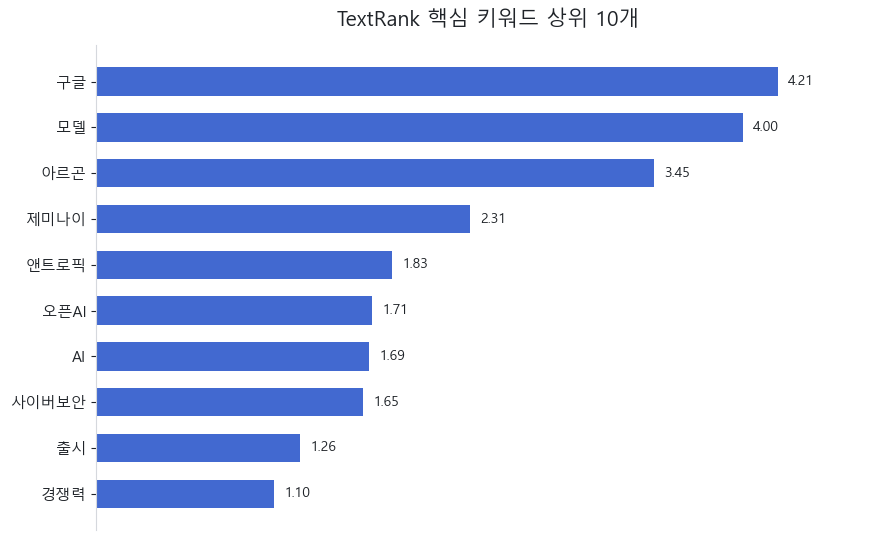

In [14]:
top10 = df_kw.head(10).iloc[::-1]          # barh 는 아래부터 그리므로 역순

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(top10["키워드"], top10["TextRank"], color=BLUE, height=0.62)

# 값은 막대 끝에 직접 적는다 (눈금선을 따라가지 않아도 읽힌다)
for b, v in zip(bars, top10["TextRank"]):
    ax.text(v + max(top10["TextRank"]) * 0.015, b.get_y() + b.get_height() / 2,
            f"{v:.2f}", va="center", fontsize=10, color=INK)

ax.set_title("TextRank 핵심 키워드 상위 10개", fontsize=15, pad=14, color=INK)
ax.set_xlabel("TextRank 점수", fontsize=11, color=MUTED)
ax.set_xlim(0, max(top10["TextRank"]) * 1.15)
ax.tick_params(colors=INK, labelsize=11)
for s in ["top", "right", "bottom"]:
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#D5D8DD")
ax.xaxis.set_visible(False)                 # 직접 라벨이 있으므로 축은 지운다
plt.tight_layout()
plt.show()

### 2-3. 보조 그래프 — 키워드 그래프(네트워크)

TextRank는 **그래프 알고리즘**이므로, 그래프 자체를 그려주면
"왜 이 단어가 상위인가"(= 어떤 단어들과 연결되어 있는가)를 함께 보여줄 수 있다.

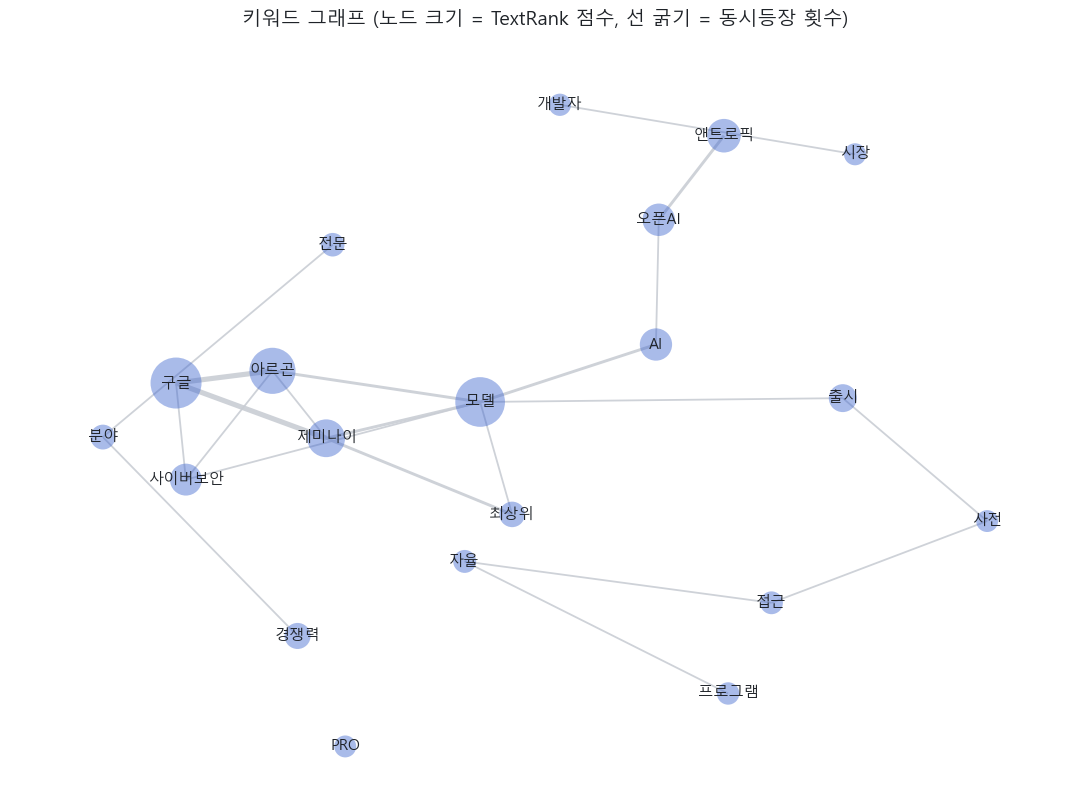

In [15]:
TOP_N = 20
top_words = df_kw.head(TOP_N)["키워드"].tolist()
top_score = dict(zip(df_kw["키워드"], df_kw["TextRank"]))

Gs = nx.Graph()
Gs.add_nodes_from(top_words)
w2i = {w: i for i, w in enumerate(vocab)}
for a in range(TOP_N):
    for b in range(a + 1, TOP_N):
        wgt = W[w2i[top_words[a]]][w2i[top_words[b]]]
        if wgt > 0:
            Gs.add_edge(top_words[a], top_words[b], weight=wgt)

pos = nx.spring_layout(Gs, seed=42, k=0.9)
sizes = [top_score[n] * 320 for n in Gs.nodes()]
ew = [Gs[u][v]["weight"] for u, v in Gs.edges()]

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(Gs, pos, ax=ax, width=[0.5 + w * 0.8 for w in ew],
                       edge_color="#C9CDD4", alpha=0.9)
# 노드 투명도 alpha값을 낮춰야 라벨이 잘 보인다
nx.draw_networkx_nodes(Gs, pos, ax=ax, node_size=sizes,
                       node_color=BLUE, alpha=0.45, linewidths=0)
nx.draw_networkx_labels(Gs, pos, ax=ax, font_size=11,
                        font_family='Malgun Gothic', font_color=INK)
ax.set_title("키워드 그래프 (노드 크기 = TextRank 점수, 선 굵기 = 동시등장 횟수)",
             fontsize=14, pad=12, color=INK)
ax.axis("off")
plt.tight_layout()
plt.show()